**BAGGING AND DECISION TREE**

We'll work with the [Indian Liver Patient](https://www.kaggle.com/datasets/uciml/indian-liver-patient-records) dataset from the UCI machine learning repository. Your task is to predict whether a patient suffers from a liver disease using 10 features including Albumin, age and gender.

In [57]:
#Import Decision Tree and Bagging Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import mean_squared_error as MSE
import matplotlib.pyplot as plt

In [47]:
#Instantiate dt and bc
dt = DecisionTreeClassifier(random_state=1)
bc = BaggingClassifier(estimator=dt, n_estimators=50, random_state=1)

In [48]:
df = pd.read_csv('/content/indian_liver_patient.csv')
df = df.dropna() # Assign the result of dropna back to df

# Encode 'Gender' column
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

X=df.drop('Dataset', axis=1)
y=df['Dataset']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=1)

In [49]:
#Fit bc and dt to the training set
bc.fit(X_train, y_train)
dt.fit(X_train, y_train)

#Predict
y_pred_bc = bc.predict(X_test)
y_pred_dt = dt.predict(X_test)

acc_test_bc = accuracy_score(y_pred_bc, y_test)
acc_test_dt = accuracy_score(y_pred_dt, y_test)
print('Test set accuracy of bc: {:.2f}'.format(acc_test_bc))
print('Test set accuracy of dt: {:.2f}'.format(acc_test_dt))

Test set accuracy of bc: 0.69
Test set accuracy of dt: 0.72


**OUT OF BAG EVALUATION**

We'll compare the OOB accuracy to the test set accuracy of a bagging classifier trained on the Indian Liver Patient dataset.

In sklearn, we can evaluate the OOB accuracy of an ensemble classifier by setting the parameter oob_score to True during instantiation. After training the classifier, the OOB accuracy can be obtained by accessing the .oob_score_ attribute from the corresponding instance.

In [50]:
#Instantiate dt
dt = DecisionTreeClassifier(min_samples_leaf=8, random_state=1)

#Instantiate bc
bc= BaggingClassifier(estimator=dt, n_estimators=50,oob_score=True, random_state=1)

In [51]:
#Fit bc and to the training set
bc.fit(X_train, y_train)

#Predict
y_pred_bc = bc.predict(X_test)

#Evaluate test accuracy
acc_test_bc = accuracy_score(y_pred_bc, y_test)

#Evaluate OOB accuracy
acc_oob_bc = bc.oob_score_

print('Test set accuracy of bc: {:.3f}'.format(acc_test_bc, acc_oob_bc))

Test set accuracy of bc: 0.698


The test set accuracy and the OOB accuracy of bc are both roughly equal to 70%

**RANDOM FOREST**

We'll predict bike rental demand in the [Capital Bikeshare](https://www.kaggle.com/competitions/bike-sharing-demand/overview) program in Washington, D.C using historical weather data from the Bike Sharing Demand dataset available through Kaggle. For this purpose, you will be using the random forests algorithm.

In [52]:
#Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split

#Import the dataset
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Preprocess 'datetime' column for both train and test sets
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour
train_df['dayofweek'] = train_df['datetime'].dt.dayofweek

test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour
test_df['dayofweek'] = test_df['datetime'].dt.dayofweek

# Drop the original 'datetime' column
train_df = train_df.drop('datetime', axis=1)
test_df = test_df.drop('datetime', axis=1)

# Drop 'casual' and 'registered' from the training features for consistent features with test_df
X_full_train = train_df.drop(['count', 'casual', 'registered'], axis=1)
y_full_train = train_df['count']

# Split the full training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_full_train, y_full_train, test_size=0.2, random_state=42)

# The X_test will be the competition's test set
X_test = test_df

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test (competition): {X_test.shape}")

Shape of X_train: (8708, 13)
Shape of y_train: (8708,)
Shape of X_val: (2178, 13)
Shape of y_val: (2178,)
Shape of X_test (competition): (6493, 13)


In [54]:
#Instantiate the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=25, random_state=2)

#Fit the model on the training set
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=25, random_state=2)

In [55]:
#Predict the validation set labels
y_pred_val = rf.predict(X_val)

# Evaluate the validation set RMSE
rmse_val = MSE(y_val, y_pred_val)**(1/2)

#Print the validation set RMSE
print("Validation set RMSE of rf is: {:.3f}".format(rmse_val))

# Predict on the actual competition test set (X_test)
y_pred_competition = rf.predict(X_test)


Validation set RMSE of rf is: 39.890


Visualizing features importances

 We'll determine which features were the most predictive according to the random forests regressor rf that we trained above

For this purpose, we'll draw a horizontal barplot of the feature importance as assessed by rf

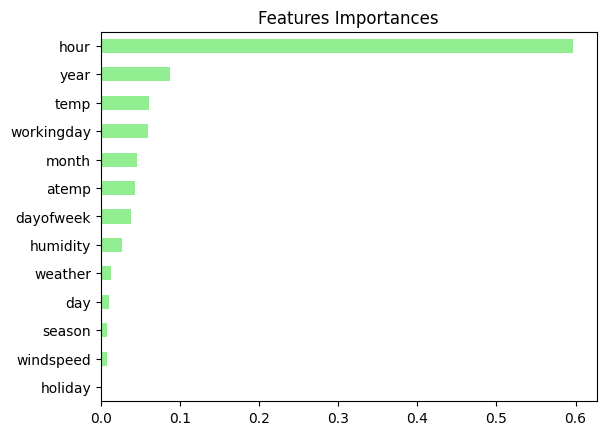

In [60]:
#Create a pd.Series of feature importances
importances = pd.Series(data=rf.feature_importances_,index=X_train.columns)

#Sort the importances
sorted_importances = importances.sort_values()

#Draw a horizontal bar plot of importances sorted
sorted_importances.plot(kind='barh', color='lightgreen')
plt.title('Features Importances')
plt.show()

As seen from the plot hour is the most important feature

In [61]:
!pip freeze > requirements.txt